Running 1000 samples (N=5000, target γ=2.5)...
Sample 01 | Initial α: 2.487 | Final α: 2.567
Sample 02 | Initial α: 2.547 | Final α: 2.580
Sample 03 | Initial α: 2.513 | Final α: 2.519
Sample 04 | Initial α: 2.571 | Final α: 2.578
Sample 05 | Initial α: 2.538 | Final α: 2.548
Sample 06 | Initial α: 2.542 | Final α: 2.550
Sample 07 | Initial α: 2.574 | Final α: 2.580
Sample 08 | Initial α: 2.584 | Final α: 2.586
Sample 09 | Initial α: 2.563 | Final α: 2.567
Sample 10 | Initial α: 2.497 | Final α: 2.504
Sample 11 | Initial α: 2.494 | Final α: 2.552
Sample 12 | Initial α: 2.636 | Final α: 2.685
Sample 13 | Initial α: 2.571 | Final α: 2.576
Sample 14 | Initial α: 2.582 | Final α: 2.589
Sample 15 | Initial α: 2.509 | Final α: 2.524
Sample 16 | Initial α: 2.517 | Final α: 2.556
Sample 17 | Initial α: 2.540 | Final α: 2.546
Sample 18 | Initial α: 2.566 | Final α: 2.695
Sample 19 | Initial α: 2.568 | Final α: 2.572
Sample 20 | Initial α: 2.585 | Final α: 2.589
Sample 21 | Initial α: 2.520 | Fi

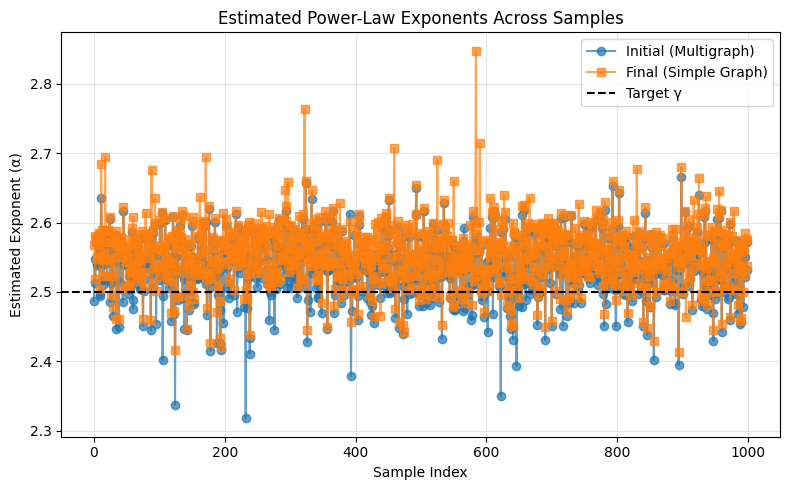

In [27]:
import networkx as nx
import numpy as np
import powerlaw
import matplotlib.pyplot as plt

def generate_and_estimate(n_nodes, target_gamma):
    """Generates a graph, cleans it, and estimates exponents before and after."""
    
    # 1. Generate sequence
    sequence = nx.utils.powerlaw_sequence(n_nodes, exponent=target_gamma)
    sequence = [max(1, int(round(s))) for s in sequence]
    if sum(sequence) % 2 != 0:
        sequence[0] += 1
        
    # 2. Build initial MultiGraph
    G_initial = nx.configuration_model(sequence)
    
    # Extract initial degrees (filter out 0s for powerlaw fitting)
    deg_init = [d for n, d in G_initial.degree() if d > 0]
    
    # Estimate initial exponent
    # verbose=False hides the printouts from the powerlaw package
    fit_init = powerlaw.Fit(deg_init, discrete=True, verbose=False)
    alpha_init = fit_init.alpha
    
    # 3. Clean the graph (remove self-loops and multiedges)
    G_initial.remove_edges_from(nx.selfloop_edges(G_initial))
    G_final = nx.Graph(G_initial) # Converts to simple graph
    
    # Extract final degrees
    deg_final = [d for n, d in G_final.degree() if d > 0]
    
    # Estimate final exponent
    fit_final = powerlaw.Fit(deg_final, discrete=True, verbose=False)
    alpha_final = fit_final.alpha
    
    return alpha_init, alpha_final

# ==========================================
# Main Execution: Run Multiple Samples
# ==========================================
n_nodes = 5000
target_gamma = 2.5
num_samples = 1000 # Number of graphs to generate

initial_alphas = []
final_alphas = []

print(f"Running {num_samples} samples (N={n_nodes}, target γ={target_gamma})...")

for i in range(num_samples):
    a_init, a_fin = generate_and_estimate(n_nodes, target_gamma)
    initial_alphas.append(a_init)
    final_alphas.append(a_fin)
    print(f"Sample {i+1:02d} | Initial α: {a_init:.3f} | Final α: {a_fin:.3f}")

# ==========================================
# Statistical Summary & Plotting
# ==========================================
mean_init = np.mean(initial_alphas)
std_init = np.std(initial_alphas)

mean_fin = np.mean(final_alphas)
std_fin = np.std(final_alphas)

print("\n" + "="*40)
print("RESULTS OVER", num_samples, "SAMPLES")
print("="*40)
print(f"Target Input Gamma : {target_gamma}")
print(f"Mean Initial Alpha : {mean_init:.4f} ± {std_init:.4f}")
print(f"Mean Final Alpha   : {mean_fin:.4f} ± {std_fin:.4f}")
print("="*40)

# Optional: Plot the shift in the estimated exponent
plt.figure(figsize=(8, 5))
plt.plot(initial_alphas, label='Initial (Multigraph)', marker='o', linestyle='-', alpha=0.7)
plt.plot(final_alphas, label='Final (Simple Graph)', marker='s', linestyle='-', alpha=0.7)
plt.axhline(target_gamma, color='black', linestyle='--', label='Target γ')

plt.title('Estimated Power-Law Exponents Across Samples')
plt.xlabel('Sample Index')
plt.ylabel('Estimated Exponent (α)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

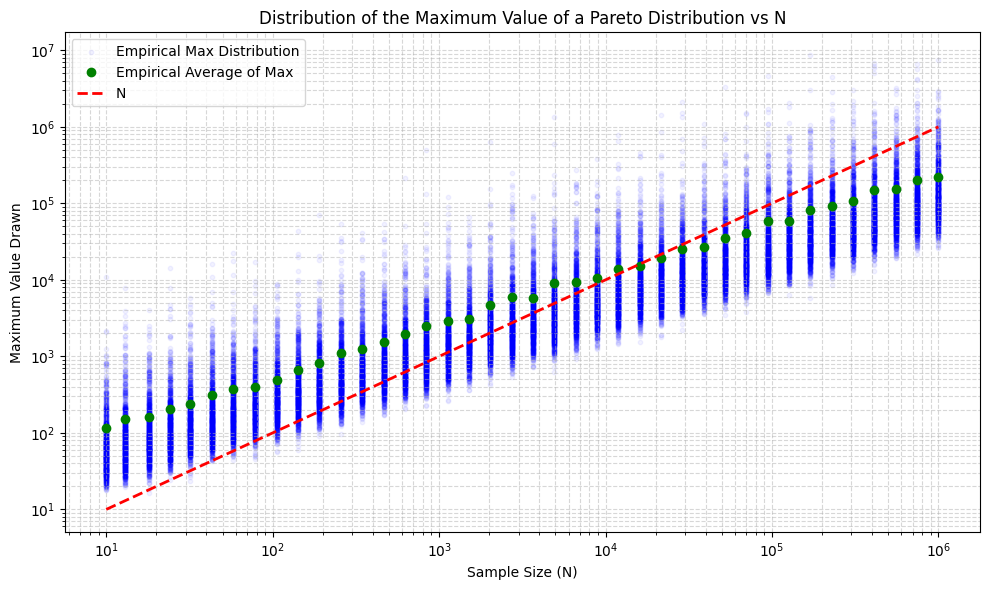

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp

alpha = 1.5
xm = 10
N_values = np.logspace(1, 6, 40, dtype=int)
trials = 1000

np.random.seed(42)

plt.figure(figsize=(10, 6))

N_grid = np.repeat(N_values, trials)
U = np.random.uniform(0, 1, size=len(N_grid))
maxes = xm / (1.0 - U**(1.0/N_grid))**(1.0/alpha)

plt.scatter(N_grid, maxes, color='blue', alpha=0.05, s=10, label='Empirical Max Distribution')

empirical_means = []
for i in range(len(N_values)):
    empirical_means.append(np.mean(maxes[i*trials : (i+1)*trials]))

plt.plot(N_values, empirical_means, marker='o', linestyle='none', color='green', markersize=6, label='Empirical Average of Max')

max_graph = N_values
plt.plot(N_values, max_graph, linestyle='--', color='red', linewidth=2, label=f'N')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample Size (N)')
plt.ylabel('Maximum Value Drawn')
plt.title('Distribution of the Maximum Value of a Pareto Distribution vs N')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()